In [1]:
#bl.sc.u4cse24170
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski as scipy_minkowski

In [2]:
df = pd.read_csv("marketing_campaign.csv", encoding="utf-8-sig")
print(df.shape)
print(df.dtypes)
df.head()

(2240, 29)
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,4/9/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,8/3/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/2/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
scales = {
    "ID": "Nominal", "Year_Birth": "Interval", "Education": "Ordinal",
    "Marital_Status": "Nominal", "Income": "Ratio", "Kidhome": "Ratio",
    "Teenhome": "Ratio", "Dt_Customer": "Interval", "Recency": "Ratio",
    "MntWines": "Ratio", "MntFruits": "Ratio", "MntMeatProducts": "Ratio",
    "MntFishProducts": "Ratio", "MntSweetProducts": "Ratio", "MntGoldProds": "Ratio",
    "NumDealsPurchases": "Ratio", "NumWebPurchases": "Ratio",
    "NumCatalogPurchases": "Ratio", "NumStorePurchases": "Ratio",
    "NumWebVisitsMonth": "Ratio",
    "AcceptedCmp1": "Nominal", "AcceptedCmp2": "Nominal", "AcceptedCmp3": "Nominal",
    "AcceptedCmp4": "Nominal", "AcceptedCmp5": "Nominal",
    "Complain": "Nominal", "Z_CostContact": "Ratio", "Z_Revenue": "Ratio",
    "Response": "Nominal",
}
pd.Series(scales, name="Scale")

,Scale
ID,Nominal
Year_Birth,Interval
Education,Ordinal
Marital_Status,Nominal
Income,Ratio
Kidhome,Ratio
Teenhome,Ratio
Dt_Customer,Interval
Recency,Ratio
MntWines,Ratio


In [5]:
def label_encode(s, order=None):
    cats = order or sorted(s.dropna().unique())
    mapping = {c: i for i, c in enumerate(cats)}
    return s.map(mapping), mapping


def one_hot_encode(s, prefix=None):
    prefix = prefix or s.name
    cats = sorted(s.dropna().unique())
    return pd.DataFrame({f"{prefix}_{c}": (s == c).astype(int) for c in cats})


edu, edu_map = label_encode(df["Education"], ["Basic", "2n Cycle", "Graduation", "Master", "PhD"])
print(edu_map)
one_hot_encode(df["Marital_Status"], "Marital").head()

{'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}


,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,0,0,0,0,1,0,0,0
1,0,0,0,0,1,0,0,0
2,0,0,0,0,0,1,0,0
3,0,0,0,0,0,1,0,0
4,0,0,0,1,0,0,0,0


In [6]:
def encode_dataset(df):
    out = df.drop(columns=["ID"]).copy()
    out["Education"], _ = label_encode(
        out["Education"], ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]
    )
    ohe = one_hot_encode(out["Marital_Status"], "Marital")
    out = pd.concat([out.drop(columns=["Marital_Status"]), ohe], axis=1)
    dates = pd.to_datetime(out["Dt_Customer"], dayfirst=True, errors="coerce")
    dates = dates.fillna(pd.to_datetime(out["Dt_Customer"], errors="coerce"))
    out["Dt_Customer"] = (dates - dates.min()).dt.days
    return out.fillna(out.median(numeric_only=True))


enc = encode_dataset(df)
X = enc.to_numpy(float)
print(f"Original: {df.shape}  Encoded: {enc.shape}")
enc.head()

Original: (2240, 29)  Encoded: (2240, 35)


,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Z_Revenue,Response,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,1957,2,58138.0,0,0,34.0,58,635,88,546,...,11,1,0,0,0,0,1,0,0,0
1,1954,2,46344.0,1,1,584.0,38,11,1,6,...,11,0,0,0,0,0,1,0,0,0
2,1965,2,71613.0,0,0,335.0,26,426,49,127,...,11,0,0,0,0,0,0,1,0,0
3,1984,2,26646.0,1,0,558.0,26,11,4,20,...,11,0,0,0,0,0,0,1,0,0
4,1981,4,58293.0,1,0,335.0,94,173,43,118,...,11,0,0,0,0,1,0,0,0,0


In [7]:
def minkowski(a, b, p=2):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(np.sum(np.abs(a - b) ** p) ** (1 / p))


print("p=1:", minkowski(X[0], X[1], 1))
print("p=2:", minkowski(X[0], X[1], 2))

p=1: 13981.0
p=2: 11837.78801127981


[(1, 13981.0), (2, 11837.78801127981), (3, 11795.374406246781), (4, 11794.050158205204), (5, 11794.001974403245), (6, 11794.000081462276), (7, 11794.000003474404), (8, 11794.000000151973), (9, 11794.000000006778), (10, 11794.000000000315)]


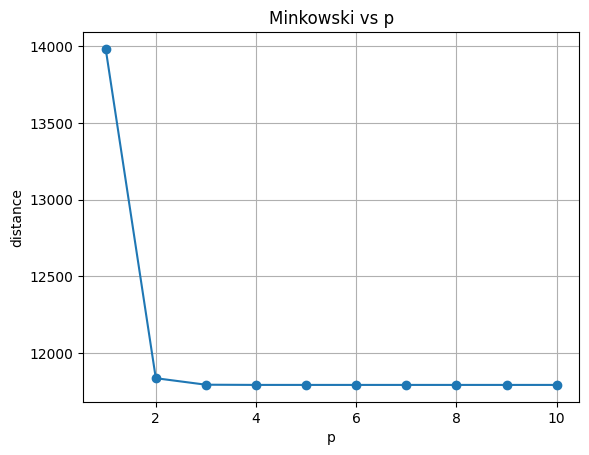

In [8]:
ps = range(1, 11)
dists = [minkowski(X[0], X[1], p) for p in ps]
print(list(zip(ps, dists)))

plt.plot(ps, dists, marker="o")
plt.xlabel("p"); plt.ylabel("distance"); plt.title("Minkowski vs p")
plt.grid(True); plt.show()

In [9]:
for p in ps:
    c, s = minkowski(X[0], X[1], p), scipy_minkowski(X[0], X[1], p)
    print(f"p={p}: custom={c:.4f}, scipy={s:.4f}, diff={abs(c-s):.2e}")

p=1: custom=13981.0000, scipy=13981.0000, diff=0.00e+00
p=2: custom=11837.7880, scipy=11837.7880, diff=0.00e+00
p=3: custom=11795.3744, scipy=11795.3744, diff=0.00e+00
p=4: custom=11794.0502, scipy=11794.0502, diff=0.00e+00
p=5: custom=11794.0020, scipy=11794.0020, diff=0.00e+00
p=6: custom=11794.0001, scipy=11794.0001, diff=0.00e+00
p=7: custom=11794.0000, scipy=11794.0000, diff=0.00e+00
p=8: custom=11794.0000, scipy=11794.0000, diff=0.00e+00
p=9: custom=11794.0000, scipy=11794.0000, diff=0.00e+00
p=10: custom=11794.0000, scipy=11794.0000, diff=0.00e+00


In [10]:
def dot(a, b):
    return float(sum(x * y for x, y in zip(a, b)))


def length(a):
    return float(sum(x * x for x in a) ** 0.5)


a, b = X[0], X[1]
print("dot :", dot(a, b), np.dot(a, b))
print("||a||:", length(a), np.linalg.norm(a))
print("||b||:", length(b), np.linalg.norm(b))

dot : 2698205021.0 2698205021.0
||a||: 58177.45219584646 58177.45219584646
||b||: 46388.870680369015 46388.870680369015


In [11]:
def mean(x):
    x = np.asarray(x, float)
    return float(x.sum() / len(x))


def variance(x):
    x = np.asarray(x, float)
    m = mean(x)
    return float(((x - m) ** 2).sum() / len(x))


def std(x):
    return variance(x) ** 0.5


def feature_stats(X, names):
    return pd.DataFrame({
        "mean": [mean(X[:, j]) for j in range(X.shape[1])],
        "var":  [variance(X[:, j]) for j in range(X.shape[1])],
        "std":  [std(X[:, j]) for j in range(X.shape[1])],
    }, index=names)


stats = feature_stats(X, enc.columns)
stats.head(10)

,mean,var,std
Year_Birth,1968.805804,1.435538e+02,11.981394
Education,2.460268,1.008243e+00,1.004113
Income,52237.975446,6.266194e+08,25032.366437
Kidhome,0.444196,2.897431e-01,0.538278
Teenhome,0.506250,2.963895e-01,0.544417
Dt_Customer,333.147768,1.657075e+04,128.727411
Recency,49.109375,8.384492e+02,28.955987
MntWines,303.935714,1.132472e+05,336.522251
MntFruits,26.302232,1.581220e+03,39.764555
MntMeatProducts,166.950000,5.092468e+04,225.664984


In [12]:
cmp = pd.DataFrame({
    "custom_mean": stats["mean"],
    "numpy_mean": np.mean(X, axis=0),
    "custom_std": stats["std"],
    "numpy_std": np.std(X, axis=0),
})
print("max mean diff:", (cmp["custom_mean"] - cmp["numpy_mean"]).abs().max())
print("max std  diff:", (cmp["custom_std"] - cmp["numpy_std"]).abs().max())
cmp.head(10)

max mean diff: 0.0
max std  diff: 0.0


,custom_mean,numpy_mean,custom_std,numpy_std
Year_Birth,1968.805804,1968.805804,11.981394,11.981394
Education,2.460268,2.460268,1.004113,1.004113
Income,52237.975446,52237.975446,25032.366437,25032.366437
Kidhome,0.444196,0.444196,0.538278,0.538278
Teenhome,0.506250,0.506250,0.544417,0.544417
Dt_Customer,333.147768,333.147768,128.727411,128.727411
Recency,49.109375,49.109375,28.955987,28.955987
MntWines,303.935714,303.935714,336.522251,336.522251
MntFruits,26.302232,26.302232,39.764555,39.764555
MntMeatProducts,166.950000,166.950000,225.664984,225.664984


mean: 52237.97544642857 var: 626619369.4507364


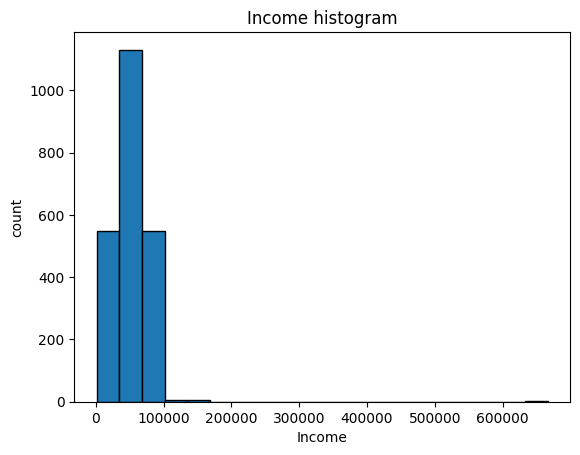

In [13]:
income = enc["Income"].to_numpy()
counts, edges = np.histogram(income, bins=20)
print("mean:", mean(income), "var:", variance(income))

plt.hist(income, bins=20, edgecolor="black")
plt.xlabel("Income"); plt.ylabel("count"); plt.title("Income histogram")
plt.show()

cluster sizes: [ 512  575 1153]


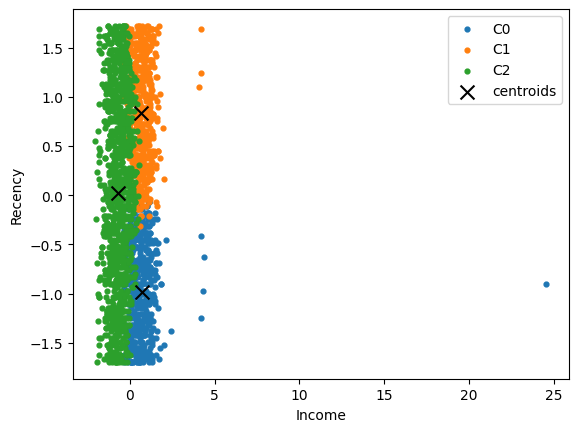

In [14]:
def kmeans(X, k=3, max_iter=50, seed=42):
    rng = np.random.default_rng(seed)
    C = X[rng.choice(len(X), k, replace=False)].copy()
    for _ in range(max_iter):
        labels = np.array([np.argmin([minkowski(x, c, 2) for c in C]) for x in X])
        new_C = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else C[j]
            for j in range(k)
        ])
        if np.allclose(C, new_C):
            break
        C = new_C
    return labels, C


# small standardized subset for a quick 2D view
cols = ["Income", "Recency", "MntWines"]
Xs = enc[cols].to_numpy(float)
Xs = (Xs - Xs.mean(0)) / Xs.std(0)

labels, C = kmeans(Xs, k=3)
print("cluster sizes:", np.bincount(labels))

for j in range(3):
    plt.scatter(Xs[labels == j, 0], Xs[labels == j, 1], s=12, label=f"C{j}")
plt.scatter(C[:, 0], C[:, 1], c="black", marker="x", s=100, label="centroids")
plt.xlabel("Income"); plt.ylabel("Recency"); plt.legend(); plt.show()